# Zadanie 2: Klasyfikacja wieloklasowa - Klasyfikacja typów irysa

In [82]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

import optuna

In [83]:
data = pd.read_csv("../Data/Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [84]:
data.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [86]:
X = data.drop(['Id','Species'],axis=1)
y = data['Species']

X.shape,y.shape

((150, 4), (150,))

In [87]:
import matplotlib.pyplot as plt

(array([[ 0.,  0.,  0.,  0.,  0., 11., 48., 49., 31., 11.],
        [ 0.,  0., 11., 97., 38.,  4.,  0.,  0.,  0.,  0.],
        [ 0., 44.,  6.,  1., 10., 34., 30., 20.,  5.,  0.],
        [50., 52., 45.,  3.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([0.1 , 0.88, 1.66, 2.44, 3.22, 4.  , 4.78, 5.56, 6.34, 7.12, 7.9 ]),
 <a list of 4 BarContainer objects>)

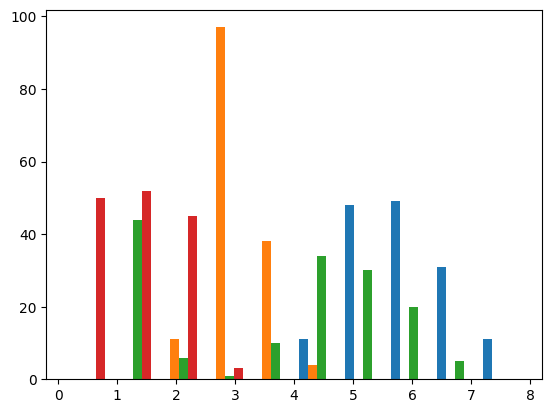

In [88]:
plt.hist(X)

In [89]:
def RobustMinMaxScaler(X,q):
    X_min = np.percentile(X, q, axis=0)
    X_max = np.percentile(X, 100 - q, axis=0)

    X_robust_minmax = (X - X_min) / (X_max - X_min)
    
    X_robust_minmax = np.clip(X_robust_minmax,0,1)    

    return X_robust_minmax

In [90]:
from sklearn.base import BaseEstimator,TransformerMixin

In [91]:
class RobustMinMaxScalerTransformer(BaseEstimator,TransformerMixin):
    def __init__(self,q,clip_flag=True):
        self.q = q
        self.clip_flag = clip_flag
        self.X_min = None
        self.X_max = None

    def fit(self,X,y=None):
        self.X_min = np.percentile(X, self.q, axis=0)
        self.X_max = np.percentile(X, 100 - self.q, axis=0)

        return self
    
    def transform(self,X):
        X_robust_minmax = (X - self.X_min) / (self.X_max - self.X_min)

        if self.clip_flag:
            X_robust_minmax = np.clip(X_robust_minmax,0,1) 
        
        return X_robust_minmax

In [92]:
test = RobustMinMaxScaler(X,25)

test

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.000000,1.0,0.000000,0.0
1,0.000000,0.4,0.000000,0.0
2,0.000000,0.8,0.000000,0.0
3,0.000000,0.6,0.000000,0.0
4,0.000000,1.0,0.000000,0.0
...,...,...,...,...
145,1.000000,0.4,1.000000,1.0
146,0.923077,0.0,0.971429,1.0
147,1.000000,0.4,1.000000,1.0
148,0.846154,1.0,1.000000,1.0


(array([[45.,  1.,  6., 13.,  8.,  7.,  9.,  6.,  4., 51.],
        [47.,  0., 10.,  0., 26.,  0., 12.,  0., 13., 42.],
        [50.,  0.,  0.,  0.,  3.,  3., 10.,  9., 20., 55.],
        [48.,  2.,  0.,  0.,  7.,  8., 13., 20.,  4., 48.]]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 4 BarContainer objects>)

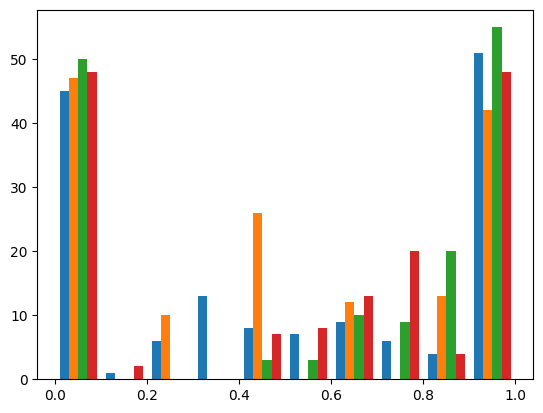

In [93]:
plt.hist(test)

In [94]:
def create_best_model(X_train,y_train,model_name):
    skf = StratifiedKFold(n_splits=5,shuffle=True)

    def objective(trial:optuna.trial.Trial):
        n_features = trial.suggest_int("n_features",1,X_train.shape[1])
        estimator_name = trial.suggest_categorical("estimator_name",["SVC","GBC"])

        if model_name == "LR":
            penalty = trial.suggest_categorical("penalty", [None,"l2","l1"])

            if penalty == "l1":
                solver = "liblinear"
            else:
                solver = "lbfgs"
            
            model = LogisticRegression(penalty=penalty,solver=solver)
        elif model_name == "KNN":
            n_neighbors = trial.suggest_int("n_neighbors",2,5)

            model = KNeighborsClassifier(n_neighbors=n_neighbors)
        
        if estimator_name == "SVC":
            estimator = SVC(kernel="linear")
        elif estimator_name == "GBC": 
            estimator = GradientBoostingClassifier()

        preprocessor = trial.suggest_categorical("preprocessor",["StandardScaler","MinMaxScaler","RobustScaler","RobustMinMaxScaler"])

        if preprocessor == "StandardScaler":
            preprocessor = StandardScaler()
        elif preprocessor == "MinMaxScaler":
            preprocessor = MinMaxScaler()
        elif preprocessor == "RobustScaler":
            preprocessor = RobustScaler()
        elif preprocessor == "RobustMinMaxScaler":
            q = trial.suggest_float("q",2.5,30,step=0.5)
            flag = trial.suggest_categorical("flag",["No","Yes"])
            flag_clip = True
            if flag == "No":
                flag_clip = False
                
            preprocessor = RobustMinMaxScalerTransformer(q,clip_flag=flag_clip)

        pipe = Pipeline([
            ("Preprocessor",preprocessor),
            ("RFE",RFE(estimator=estimator,n_features_to_select=n_features)),
            ("Classifier",model)
        ])

        scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=skf,
            scoring="f1_macro",
            n_jobs=-1
        )

        return scores.mean()
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective,n_trials=30)

    return study.best_params, study.best_value


In [95]:
val_cv = StratifiedKFold(n_splits=5,shuffle=True)

In [96]:
results = {
    "accuracy_lr": [],
    "accuracy_knn": [],
    "precission_lr": [],
    "precission_knn": [],
    "recall_lr": [],
    "recall_knn": [],
    "f1_lr": [],
    "f1_knn": [],
}

In [97]:
fold_idx = 0

for train_idx,test_idx in val_cv.split(X,y):
    fold_idx += 1

    X_train,X_test = X.iloc[train_idx],X.iloc[test_idx]
    y_train,y_test = y.iloc[train_idx],y.iloc[test_idx]

    best_params_lr, best_score_lr = create_best_model(X_train,y_train,"LR")

    if best_params_lr['estimator_name'] == "SVC":
        estimator = SVC(kernel='linear')
    else:
        estimator = GradientBoostingClassifier()

    if best_params_lr['preprocessor'] == "StandardScaler":
        best_params_lr['preprocessor'] = StandardScaler()
    elif best_params_lr['preprocessor'] == "MinMaxScaler":
        best_params_lr['preprocessor'] = MinMaxScaler()
    elif best_params_lr['preprocessor'] == "RobustScaler":
        best_params_lr['preprocessor'] = RobustScaler()
    elif best_params_lr['preprocessor'] == "RobustMinMaxScaler":
        q = best_params_lr["q"]
        flag = best_params_lr["flag"]
        if flag:
            f_c = True
        else:
            f_c = False

        best_params_lr['preprocessor'] = RobustMinMaxScalerTransformer(q,clip_flag=f_c)

    pipeline = Pipeline([
        ("Preprocessor",best_params_lr['preprocessor']),
        ("RFE",RFE(estimator=estimator,n_features_to_select=best_params_lr["n_features"])),
        ("Classifier",LogisticRegression(
            penalty=best_params_lr['penalty'],
            solver = "liblinear" if best_params_lr['penalty'] == "l1" else "lbfgs"
        ))
    ])

    pipeline.fit(X_train,y_train)
    preds_lr = pipeline.predict(X_test)

    TP = np.sum((y_test == 1) & (preds_lr == 1))
    TN = np.sum((y_test == 0) & (preds_lr == 0))
    FP = np.sum((y_test == 0) & (preds_lr == 1))
    FN = np.sum((y_test == 1) & (preds_lr == 0))

    # accuracy = (TP + TN) / (TP + TN + FP + FN)
    # precission = TP / (TP + FP)
    # recall = TP / (TP + FN)
    accuracy = accuracy_score(y_test,preds_lr)
    precission = precision_score(y_test,preds_lr,average='macro')
    recall = recall_score(y_test,preds_lr,average='macro')
    f1 = f1_score(y_test,preds_lr,average='macro')
 
    results["accuracy_lr"].append(accuracy)
    results["precission_lr"].append(precission)
    results["recall_lr"].append(recall)
    results["f1_lr"].append(f1)

    best_params_knn,best_score_knn = create_best_model(X_train,y_train,"KNN")

    if best_params_knn['estimator_name'] == "SVC":
        estimator = SVC(kernel="linear")
    else:
        estimator = GradientBoostingClassifier()

    if best_params_knn['preprocessor'] == "StandardScaler":
        best_params_knn['preprocessor'] = StandardScaler()
    elif best_params_knn['preprocessor'] == "MinMaxScaler":
        best_params_knn['preprocessor'] = MinMaxScaler()
    elif best_params_knn['preprocessor'] == "RobustScaler":
        best_params_knn['preprocessor'] = RobustScaler()
    elif best_params_knn['preprocessor'] == "RobustMinMaxScaler":
        q = best_params_knn["q"]
        flag = best_params_knn["flag"]
        if flag:
            f_c = True
        else:
            f_c = False

        best_params_knn['preprocessor'] = RobustMinMaxScalerTransformer(q,clip_flag=f_c)

    pipeline = Pipeline([
        ("Preprocessor",best_params_knn['preprocessor']),
        ("RFE",RFE(estimator=estimator,n_features_to_select=best_params_knn["n_features"])),
        ("classificator", KNeighborsClassifier(
            n_neighbors=best_params_knn["n_neighbors"]
        ))
    ])
    
    pipeline.fit(X_train,y_train)
    preds_knn = pipeline.predict(X_test)

    TP = np.sum((preds_knn == 1) & (y_test == 1))
    TN = np.sum((preds_knn == 0) & (y_test == 0))
    FP = np.sum((preds_knn == 1) & (y_test == 0))
    FN = np.sum((preds_knn == 0) & (y_test == 1))

    # accuracy = (TP + TN) / (TP + TN + FP + FN)
    # precission = TP / (TP + FP)
    # recall = TP / (TP + FN)
    accuracy = accuracy_score(y_test,preds_knn)
    precission = precision_score(y_test,preds_knn,average='macro')
    recall = recall_score(y_test,preds_knn,average='macro')
    f1 = f1_score(y_test,preds_knn,average="macro")

    results["accuracy_knn"].append(accuracy)
    results["precission_knn"].append(precission)
    results["recall_knn"].append(recall)
    results["f1_knn"].append(f1)
    print(f"Fold {fold_idx} completed.")

for key in results.keys():
    results[key] = np.mean(results[key])

results    

[I 2025-12-03 11:29:01,162] A new study created in memory with name: no-name-1488d459-0357-49b3-8d86-f69a96c7a8cb
[I 2025-12-03 11:29:04,664] Trial 0 finished with value: 0.9577715530656707 and parameters: {'n_features': 1, 'estimator_name': 'GBC', 'penalty': None, 'preprocessor': 'StandardScaler'}. Best is trial 0 with value: 0.9577715530656707.
[I 2025-12-03 11:29:07,041] Trial 1 finished with value: 0.9246374105197634 and parameters: {'n_features': 4, 'estimator_name': 'GBC', 'penalty': 'l2', 'preprocessor': 'RobustMinMaxScaler', 'q': 16.5, 'flag': 'Yes'}. Best is trial 0 with value: 0.9577715530656707.
[I 2025-12-03 11:29:09,025] Trial 2 finished with value: 0.9579707438530969 and parameters: {'n_features': 2, 'estimator_name': 'SVC', 'penalty': None, 'preprocessor': 'RobustMinMaxScaler', 'q': 16.5, 'flag': 'Yes'}. Best is trial 2 with value: 0.9579707438530969.
[I 2025-12-03 11:29:09,118] Trial 3 finished with value: 0.9749019607843138 and parameters: {'n_features': 3, 'estimator_

Fold 1 completed.


[I 2025-12-03 11:29:18,395] Trial 3 finished with value: 0.8875899023577043 and parameters: {'n_features': 4, 'estimator_name': 'GBC', 'penalty': 'l1', 'preprocessor': 'RobustMinMaxScaler', 'q': 24.0, 'flag': 'Yes'}. Best is trial 2 with value: 0.9665359477124185.
[I 2025-12-03 11:29:18,433] Trial 4 finished with value: 0.9663367569249923 and parameters: {'n_features': 2, 'estimator_name': 'SVC', 'penalty': None, 'preprocessor': 'RobustScaler'}. Best is trial 2 with value: 0.9665359477124185.
[I 2025-12-03 11:29:19,116] Trial 5 finished with value: 0.8914882720765073 and parameters: {'n_features': 2, 'estimator_name': 'GBC', 'penalty': 'l1', 'preprocessor': 'RobustMinMaxScaler', 'q': 4.5, 'flag': 'No'}. Best is trial 2 with value: 0.9665359477124185.
[I 2025-12-03 11:29:19,154] Trial 6 finished with value: 0.8869249922191098 and parameters: {'n_features': 1, 'estimator_name': 'SVC', 'penalty': 'l1', 'preprocessor': 'RobustMinMaxScaler', 'q': 20.5, 'flag': 'Yes'}. Best is trial 2 with v

Fold 2 completed.


[I 2025-12-03 11:29:37,721] Trial 3 finished with value: 0.9499346405228758 and parameters: {'n_features': 2, 'estimator_name': 'SVC', 'penalty': 'l2', 'preprocessor': 'RobustMinMaxScaler', 'q': 27.0, 'flag': 'No'}. Best is trial 3 with value: 0.9499346405228758.
[I 2025-12-03 11:29:38,750] Trial 4 finished with value: 0.9415032679738562 and parameters: {'n_features': 1, 'estimator_name': 'GBC', 'penalty': None, 'preprocessor': 'StandardScaler'}. Best is trial 3 with value: 0.9499346405228758.
[I 2025-12-03 11:29:39,723] Trial 5 finished with value: 0.907177093059446 and parameters: {'n_features': 1, 'estimator_name': 'GBC', 'penalty': None, 'preprocessor': 'RobustScaler'}. Best is trial 3 with value: 0.9499346405228758.
[I 2025-12-03 11:29:39,811] Trial 6 finished with value: 0.8816645434602091 and parameters: {'n_features': 3, 'estimator_name': 'SVC', 'penalty': 'l2', 'preprocessor': 'RobustMinMaxScaler', 'q': 26.5, 'flag': 'Yes'}. Best is trial 3 with value: 0.9499346405228758.
[I 2

...

[I 2025-12-03 11:29:55,907] Trial 2 finished with value: 0.932324362943558 and parameters: {'n_features': 1, 'estimator_name': 'GBC', 'penalty': 'l2', 'preprocessor': 'RobustMinMaxScaler', 'q': 9.5, 'flag': 'No'}. Best is trial 1 with value: 0.958036103330221.
[I 2025-12-03 11:29:55,955] Trial 3 finished with value: 0.9240024898848427 and parameters: {'n_features': 2, 'estimator_name': 'SVC', 'penalty': 'l1', 'preprocessor': 'RobustScaler'}. Best is trial 1 with value: 0.958036103330221.
[I 2025-12-03 11:29:56,261] Trial 4 finished with value: 0.924448545950094 and parameters: {'n_features': 4, 'estimator_name': 'GBC', 'penalty': 'l2', 'preprocessor': 'RobustMinMaxScaler', 'q': 30.0, 'flag': 'No'}. Best is trial 1 with value: 0.958036103330221.
[I 2025-12-03 11:29:57,110] Trial 5 finished with value: 0.8456090314913844 and parameters: {'n_features': 1, 'estimator_name': 'GBC', 'penalty': 'l1', 'preprocessor': 'RobustMinMaxScaler', 'q': 25.0, 'flag': 'Yes'}. Best is trial 1 with value: 

Fold 4 completed.


[I 2025-12-03 11:30:11,294] Trial 0 finished with value: 0.9326735138499845 and parameters: {'n_features': 1, 'estimator_name': 'GBC', 'penalty': 'l2', 'preprocessor': 'MinMaxScaler'}. Best is trial 0 with value: 0.9326735138499845.
[I 2025-12-03 11:30:11,349] Trial 1 finished with value: 0.9496047307812013 and parameters: {'n_features': 2, 'estimator_name': 'SVC', 'penalty': 'l2', 'preprocessor': 'MinMaxScaler'}. Best is trial 1 with value: 0.9496047307812013.
[I 2025-12-03 11:30:11,416] Trial 2 finished with value: 0.9496700902583257 and parameters: {'n_features': 2, 'estimator_name': 'SVC', 'penalty': None, 'preprocessor': 'RobustMinMaxScaler', 'q': 25.0, 'flag': 'Yes'}. Best is trial 2 with value: 0.9496700902583257.
[I 2025-12-03 11:30:11,705] Trial 3 finished with value: 0.9070271329404456 and parameters: {'n_features': 4, 'estimator_name': 'GBC', 'penalty': 'l1', 'preprocessor': 'StandardScaler'}. Best is trial 2 with value: 0.9496700902583257.
[I 2025-12-03 11:30:12,388] Trial 

Fold 5 completed.


{'accuracy_lr': np.float64(0.9533333333333334),
 'accuracy_knn': np.float64(0.9400000000000001),
 'precission_lr': np.float64(0.9581002331002331),
 'precission_knn': np.float64(0.9447668997668999),
 'recall_lr': np.float64(0.9533333333333334),
 'recall_knn': np.float64(0.9400000000000001),
 'f1_lr': np.float64(0.9529306357681644),
 'f1_knn': np.float64(0.939597302434831)}

In [98]:
best_params_lr

{'n_features': 1,
 'estimator_name': 'SVC',
 'penalty': None,
 'preprocessor': RobustScaler()}

In [99]:
best_params_knn

{'n_features': 1,
 'estimator_name': 'SVC',
 'n_neighbors': 5,
 'preprocessor': RobustMinMaxScalerTransformer(q=11.0),
 'q': 11.0,
 'flag': 'Yes'}

In [101]:
from scipy.stats import wilcoxon

stat,p_value = wilcoxon(results["f1_lr"],results['f1_knn'])

p_value

np.float64(1.0)